## 1. Imports and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

os.makedirs("../data", exist_ok=True)

urllib.request.urlretrieve(url, "../data/bike_sharing.zip")

with zipfile.ZipFile("../data/bike_sharing.zip", "r") as zip_ref:
    zip_ref.extractall("../data")

print(os.listdir("../data"))

['bike_sharing.zip', 'day.csv', 'hour.csv', 'Readme.txt']


## 2. Initial Data Exploration

In [4]:
df = pd.read_csv("../data/hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [7]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


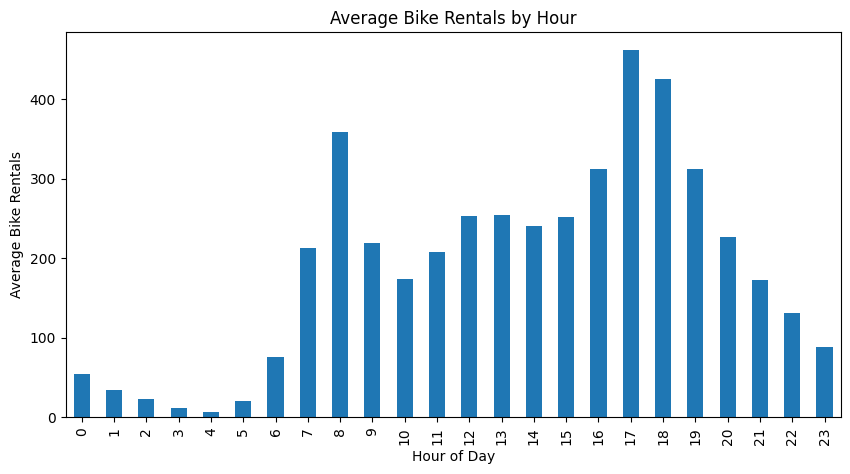

In [8]:
plt.figure(figsize=(10, 5))
df.groupby("hr")["cnt"].mean().plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Average Bike Rentals")
plt.title("Average Bike Rentals by Hour")
plt.show()

## 3. Baseline Linear Regression Model

In [9]:
features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

X = df[features]
y = df["cnt"]

In [10]:
X.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [11]:
y.head()

0    16
1    40
2    32
3    13
4     1
Name: cnt, dtype: int64

In [12]:
split_index = int(len(df) * 0.8)  # 80% of the data is for training. The rest is for testing. 

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 13903
Testing rows: 3476


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4. Evaluation of Baseline Model

In [14]:
y_pred = model.predict(X_test)
y_pred[:10]

array([328.53285326, 339.57627237, 355.34496387, 352.89442956,
       328.94914236, 348.10008868, 348.24673581, 350.01281357,
       343.40441274, 337.8223206 ])

In [15]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,283,328.532853
1,253,339.576272
2,261,355.344964
3,306,352.894430
4,445,328.949142
5,868,348.100089
6,814,348.246736
7,610,350.012814
8,448,343.404413
9,317,337.822321


In [16]:
raw_mae = mean_absolute_error(y_test, y_pred)
raw_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
raw_r2 = r2_score(y_test, y_pred)

print("MAE:", raw_mae)
print("RMSE:", raw_rmse)
print("R²:", raw_r2)

MAE: 138.2917531082735
RMSE: 183.2778473101196
R²: 0.3090246205295294


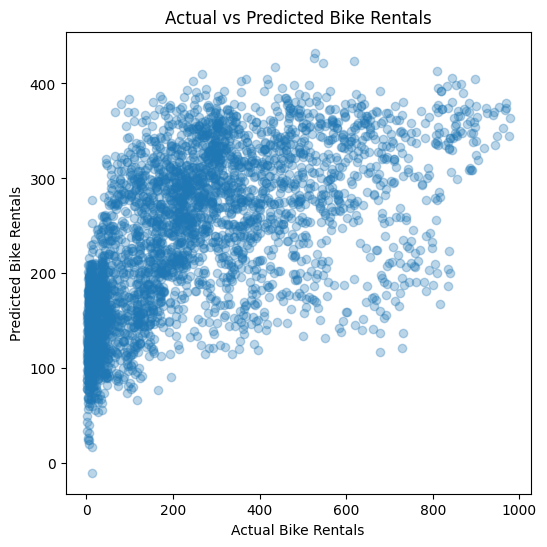

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Bike Rentals")

plt.show()

In [18]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,season,8.254586
1,yr,76.802299
2,mnth,2.505504
3,hr,7.248713
4,holiday,-21.159666
5,weekday,1.254928
6,workingday,0.825002
7,weathersit,-5.289152
8,temp,80.060513
9,atemp,214.448589


In [19]:
print(model.intercept_)

-10.97482167930275


## 5. Improved Linear Regression with One-Hot Encoding

The first model treated categorical variables like hour, season, and weather as ordinary numbers. This is a problem because hour 17 is not simply "17 times" hour 1. To improve the feature representation while still using linear regression, I one-hot encoded the categorical variables.

In [20]:
categorical_features = [
    "season",
    "mnth",
    "hr",
    "weekday",
    "weathersit"
]

numeric_features = [
    "yr",
    "holiday",
    "workingday",
    "temp",
    "hum",
    "windspeed"
]

X = df[categorical_features + numeric_features]
y = df["cnt"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

X_encoded.head()

,yr,holiday,workingday,temp,hum,windspeed,season_2,season_3,season_4,mnth_2,...,hr_23,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3,weathersit_4
0,0,0,0,0.24,0.81,0.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0,0,0,0.22,0.80,0.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,0,0,0,0.22,0.80,0.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0,0,0,0.24,0.75,0.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,0,0,0,0.24,0.75,0.0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [21]:
split_index = int(len(df) * 0.8)

X_train = X_encoded.iloc[:split_index]
X_test = X_encoded.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

model = LinearRegression()
model.fit(X_train, y_train)

encoded_y_pred = model.predict(X_test)

In [22]:
encoded_mae = mean_absolute_error(y_test, encoded_y_pred)
encoded_rmse = np.sqrt(mean_squared_error(y_test, encoded_y_pred))
encoded_r2 = r2_score(y_test, encoded_y_pred)

print("MAE:", encoded_mae)
print("RMSE:", encoded_rmse)
print("R²:", encoded_r2)

MAE: 98.86920640723012
RMSE: 134.00252941836658
R²: 0.6306240502200504


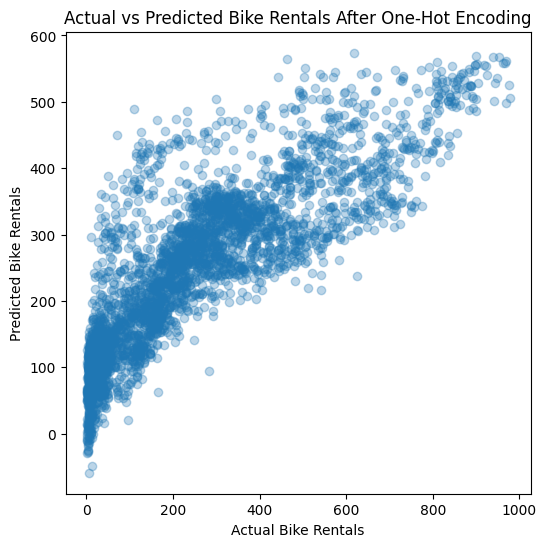

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, encoded_y_pred, alpha=0.3)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Bike Rentals After One-Hot Encoding")

plt.show()

In [24]:
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 174.98460136882977
Baseline RMSE: 232.60837481037086
Baseline R²: -0.11299526466191145


## Model Comparison

To evaluate whether the model improved, I compared three approaches:

1. Average baseline: always predicts the average bike rental count from the training data.
2. Raw linear regression: uses the original numeric-coded features directly.
3. One-hot encoded linear regression: converts categorical variables like hour, season, month, weekday, and weather into separate binary columns.

The goal is to check whether better feature representation improves prediction performance.

In [25]:
results = pd.DataFrame({
    "Model": [
        "Average baseline",
        "Raw linear regression",
        "One-hot encoded linear regression"
    ],
    "MAE": [
        baseline_mae,
        raw_mae,
        encoded_mae
    ],
    "RMSE": [
        baseline_rmse,
        raw_rmse,
        encoded_rmse
    ],
    "R²": [
        baseline_r2,
        raw_r2,
        encoded_r2
    ]
})

results

,Model,MAE,RMSE,R²
0,Average baseline,174.984601,232.608375,-0.112995
1,Raw linear regression,138.291753,183.277847,0.309025
2,One-hot encoded linear regression,98.869206,134.002529,0.630624


The one-hot encoded linear regression model performed best. Its MAE decreased from about 138 rentals in the raw linear regression model to about 99 rentals, and its R² increased from 0.309 to 0.631. This suggests that treating categorical variables properly helped the linear model capture demand patterns more effectively, especially patterns related to hour, month, season, weekday, and weather.

## Error Analysis

After improving the model with one-hot encoding, I analyzed where the model still performs poorly. Instead of only looking at overall metrics like MAE and R², I examined prediction errors by hour, weather condition, and month.

In [26]:
test_df = df.iloc[split_index:].copy()

test_df["actual"] = y_test.values
test_df["predicted"] = encoded_y_pred
test_df["error"] = test_df["predicted"] - test_df["actual"]
test_df["absolute_error"] = abs(test_df["error"])

test_df[["dteday", "hr", "weathersit", "mnth", "actual", "predicted", "error", "absolute_error"]].head(10)

,dteday,hr,weathersit,mnth,actual,predicted,error,absolute_error
13903,2012-08-07,12,2,8,283,337.323309,54.323309,54.323309
13904,2012-08-07,13,2,8,253,334.157573,81.157573,81.157573
13905,2012-08-07,14,2,8,261,336.110068,75.110068,75.110068
13906,2012-08-07,15,1,8,306,344.931741,38.931741,38.931741
13907,2012-08-07,16,3,8,445,308.478335,-136.521665,136.521665
13908,2012-08-07,17,2,8,868,518.809775,-349.190225,349.190225
13909,2012-08-07,18,2,8,814,487.284537,-326.715463,326.715463
13910,2012-08-07,19,2,8,610,387.968515,-222.031485,222.031485
13911,2012-08-07,20,2,8,448,306.000364,-141.999636,141.999636
13912,2012-08-07,21,2,8,317,258.851688,-58.148312,58.148312


In [27]:
test_df[["dteday", "hr", "weathersit", "temp", "hum", "actual", "predicted", "error", "absolute_error"]] \
    .sort_values("absolute_error", ascending=False) \
    .head(10)

,dteday,hr,weathersit,temp,hum,actual,predicted,error,absolute_error
14773,2012-09-12,18,1,0.66,0.44,977,505.354827,-471.645173,471.645173
14725,2012-09-10,18,1,0.62,0.35,968,498.781239,-469.218761,469.218761
14964,2012-09-20,17,1,0.64,0.50,976,525.629297,-450.370703,450.370703
14293,2012-08-23,18,1,0.74,0.48,941,501.452831,-439.547169,439.547169
15031,2012-09-23,12,1,0.56,0.43,776,343.552119,-432.447881,432.447881
15849,2012-10-27,14,1,0.60,0.46,750,333.636545,-416.363455,416.363455
14695,2012-09-09,12,1,0.66,0.47,757,341.823341,-415.176659,415.176659
15588,2012-10-16,17,1,0.52,0.39,943,528.063765,-414.936235,414.936235
15627,2012-10-18,8,1,0.46,0.82,834,419.163801,-414.836199,414.836199
14965,2012-09-20,18,1,0.60,0.56,900,485.649815,-414.350185,414.350185


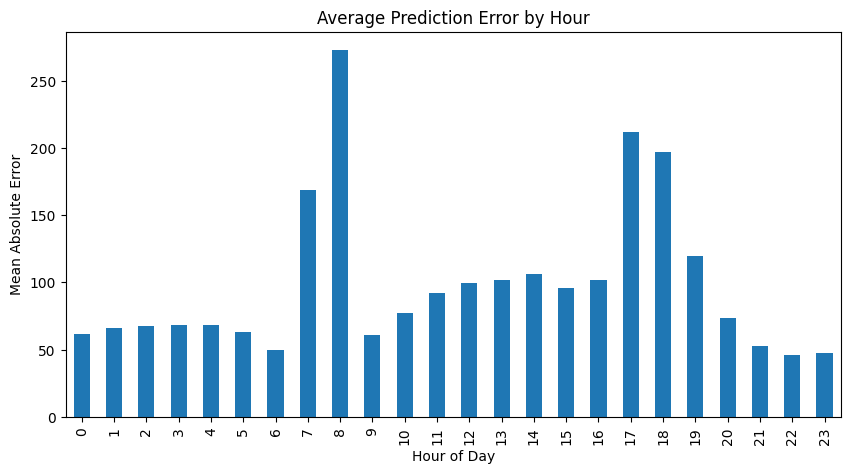

In [28]:
error_by_hour = test_df.groupby("hr")["absolute_error"].mean()

plt.figure(figsize=(10, 5))
error_by_hour.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error")
plt.title("Average Prediction Error by Hour")
plt.show()

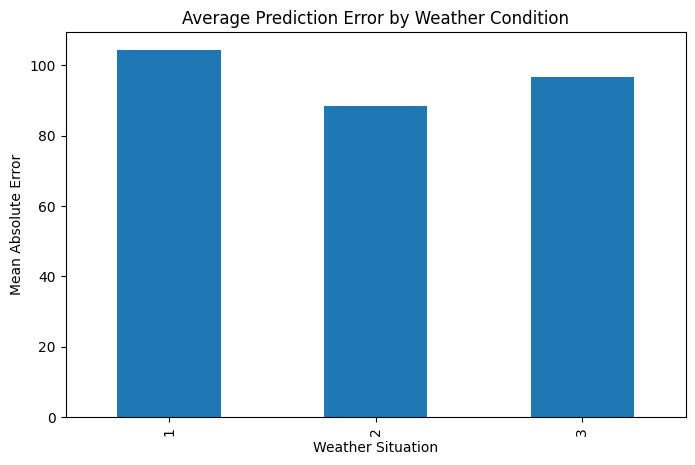

In [29]:
error_by_weather = test_df.groupby("weathersit")["absolute_error"].mean()

plt.figure(figsize=(8, 5))
error_by_weather.plot(kind="bar")

plt.xlabel("Weather Situation")
plt.ylabel("Mean Absolute Error")
plt.title("Average Prediction Error by Weather Condition")
plt.show()

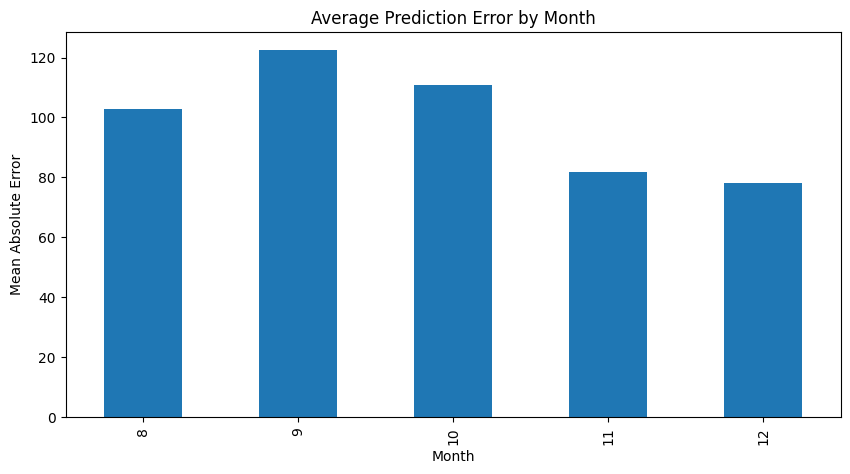

In [30]:
error_by_month = test_df.groupby("mnth")["absolute_error"].mean()

plt.figure(figsize=(10, 5))
error_by_month.plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Mean Absolute Error")
plt.title("Average Prediction Error by Month")
plt.show()

## Error Analysis Findings

The error analysis shows that the improved one-hot encoded linear regression model still struggles most during peak commute hours.

The largest prediction errors occur around 8 AM and 5–6 PM, which correspond to typical morning and evening commute periods. In the table of the largest errors, the model consistently underpredicts very high-demand observations. For example, several actual demand values are above 900 rentals, but the model predicts values closer to 500. This suggests that the model captures general demand patterns but still fails to fully account for sharp rush-hour spikes.

The error by weather condition does not show as strong of a pattern. The average error is somewhat different across weather categories, but the differences are much smaller than the differences by hour. This suggests that weather affects demand, but it is not the main reason for the model’s largest mistakes.

The error by month also shows some variation, with higher errors in months such as September and October, but the pattern is not as clear or extreme as the hour-based error pattern. This may partly be because the test set only includes later months of the year due to the time-based train/test split.

Overall, the main weakness of the model appears to be its inability to fully capture commute-related demand spikes. Next, i will add explicit features for morning and evening commute periods on working days.

## Feature Engineering: Commute Periods

Based on the error analysis, I added new binary features to help the model identify high-demand commute periods. They give the model more useful information about specific time patterns that caused large errors.

In [31]:
df["morning_commute"] = ((df["hr"].isin([7, 8])) & (df["workingday"] == 1)).astype(int)
df["evening_commute"] = ((df["hr"].isin([17, 18])) & (df["workingday"] == 1)).astype(int)
df["weekend"] = df["weekday"].isin([0, 6]).astype(int)

In [32]:
categorical_features = [
    "season",
    "mnth",
    "hr",
    "weekday",
    "weathersit"
]

numeric_features = [
    "yr",
    "holiday",
    "workingday",
    "temp",
    "hum",
    "windspeed",
    "morning_commute",
    "evening_commute",
    "weekend"
]

X = df[categorical_features + numeric_features]
y = df["cnt"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

split_index = int(len(df) * 0.8)

X_train = X_encoded.iloc[:split_index]
X_test = X_encoded.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

engineered_model = LinearRegression()
engineered_model.fit(X_train, y_train)

engineered_y_pred = engineered_model.predict(X_test)

In [33]:
engineered_mae = mean_absolute_error(y_test, engineered_y_pred)
engineered_rmse = np.sqrt(mean_squared_error(y_test, engineered_y_pred))
engineered_r2 = r2_score(y_test, engineered_y_pred)

print("MAE:", engineered_mae)
print("RMSE:", engineered_rmse)
print("R²:", engineered_r2)

MAE: 87.65450779923142
RMSE: 116.40376158294897
R²: 0.721274532767022


## Comparison with Previous Models

In [34]:
comparison_results = pd.DataFrame({
    "Model": [
        "Average baseline",
        "Raw linear regression",
        "One-hot encoded linear regression",
        "Engineered linear regression"
    ],
    "MAE": [
        baseline_mae,
        raw_mae,
        encoded_mae,
        engineered_mae
    ],
    "RMSE": [
        baseline_rmse,
        raw_rmse,
        encoded_rmse,
        engineered_rmse
    ],
    "R²": [
        baseline_r2,
        raw_r2,
        encoded_r2,
        engineered_r2
    ]
})

comparison_results

,Model,MAE,RMSE,R²
0,Average baseline,174.984601,232.608375,-0.112995
1,Raw linear regression,138.291753,183.277847,0.309025
2,One-hot encoded linear regression,98.869206,134.002529,0.630624
3,Engineered linear regression,87.654508,116.403762,0.721275


## Engineered Model Results

After the error analysis showed that the one-hot encoded model struggled most during commute hours, I added explicit binary features for morning commute, evening commute, and weekend observations.

This improved the model noticeably. The MAE decreased from about 98.87 rentals to 87.65 rentals, while R² increased from 0.631 to 0.721. This suggests that the engineered commute features helped the linear model better capture peak demand patterns that were not fully represented by the original features alone.

In [35]:
# Error analysis for one-hot encoded model
encoded_test_df = df.iloc[split_index:].copy()
encoded_test_df["actual"] = y_test.values
encoded_test_df["predicted"] = encoded_y_pred
encoded_test_df["absolute_error"] = abs(encoded_test_df["predicted"] - encoded_test_df["actual"])

encoded_error_by_hour = encoded_test_df.groupby("hr")["absolute_error"].mean()


# Error analysis for engineered model
engineered_test_df = df.iloc[split_index:].copy()
engineered_test_df["actual"] = y_test.values
engineered_test_df["predicted"] = engineered_y_pred
engineered_test_df["absolute_error"] = abs(engineered_test_df["predicted"] - engineered_test_df["actual"])

engineered_error_by_hour = engineered_test_df.groupby("hr")["absolute_error"].mean()


# Compare errors by hour
hour_error_comparison = pd.DataFrame({
    "One-hot model error": encoded_error_by_hour,
    "Engineered model error": engineered_error_by_hour
})

hour_error_comparison

,One-hot model error,Engineered model error
hr,,
0,61.757215,57.441524
1,66.227809,62.152009
2,67.790845,66.514534
3,68.044487,69.676723
4,68.736189,69.880147
5,63.374761,64.914274
6,49.461015,61.393643
7,168.504872,74.015145
8,272.575374,169.149712


<Figure size 1200x500 with 0 Axes>

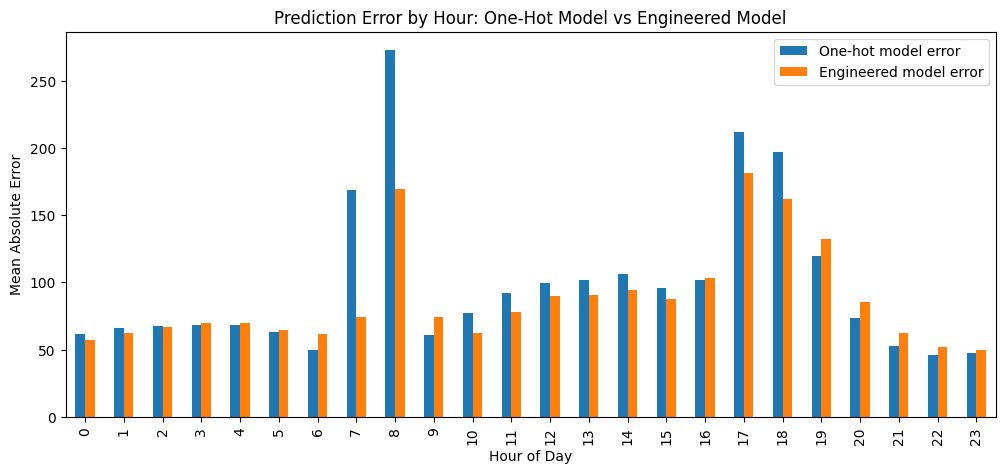

In [36]:
plt.figure(figsize=(12, 5))

hour_error_comparison.plot(kind="bar", figsize=(12, 5))

plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Hour: One-Hot Model vs Engineered Model")
plt.show()

## Effect of Commute Feature Engineering

The comparison between the one-hot encoded model and the engineered model shows that the new commute-related features improved the model's performance, especially during peak demand periods.

The largest improvement occurs around the morning commute period, particularly at **7 AM** and **8 AM**. The one-hot encoded model had very high error during these hours, but the engineered model reduced that error substantially. This suggests that explicitly identifying working-day commute periods helped the linear regression model better capture rush-hour demand spikes.

The engineered model also improves prediction error during the evening commute period, especially around **5 PM** and **6 PM**, although the error remains relatively high compared to non-commute hours. This suggests that evening demand is still harder to predict, possibly because it depends on more factors than the dataset captures.

Overall, this confirms that the error analysis was useful: by identifying where the model performed poorly, I was able to create targeted features that improved the model while still using linear regression.

## Linear Regression Takeaways

The linear regression experiments show a clear improvement across three stages:

1. The raw linear regression model performed weakly because it treated categorical variables such as hour, month, season, weekday, and weather as ordinary numerical values.
2. One-hot encoding improved performance by allowing the model to learn separate effects for each category.
3. Error analysis showed that the model struggled most during commute hours, so I added engineered features for morning commute, evening commute, and weekends.
4. These engineered features further improved performance, increasing R² to about 0.72 and reducing MAE to about 88 rentals.

This shows that model performance improved not because of a more complex algorithm, but because of better feature representation and targeted feature engineering.